<a href="https://colab.research.google.com/github/Krishishah7/nlp-learning-series/blob/main/03_search/search_similarity_score_interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpreting Similarity Scores in Semantic Search

## Objective
This notebook analyzes similarity score ranges in semantic search
to understand what different cosine similarity values represent
in terms of semantic relevance.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [ ]:
query = "learn machine learning basics"

documents = [
    "Machine learning tutorials for beginners",
    "Introduction to deep learning",
    "Natural language processing with transformers",
    "Python programming fundamentals",
    "Football match highlights",
    "Top travel destinations"
]

In [7]:
query_emb = model.encode(query)
doc_embs = model.encode(documents)

scores = cosine_similarity([query_emb], doc_embs)[0]

df = pd.DataFrame({
    "Document": documents,
    "Similarity Score": np.round(scores, 4)
}).sort_values(by="Similarity Score", ascending=False)

df

,Document,Similarity Score
0,Machine learning tutorials for beginners,0.8806
1,Introduction to deep learning,0.5455
3,Python programming fundamentals,0.3898
2,Natural language processing with transformers,0.2065
4,Football match highlights,0.0823
5,Top travel destinations,0.0293


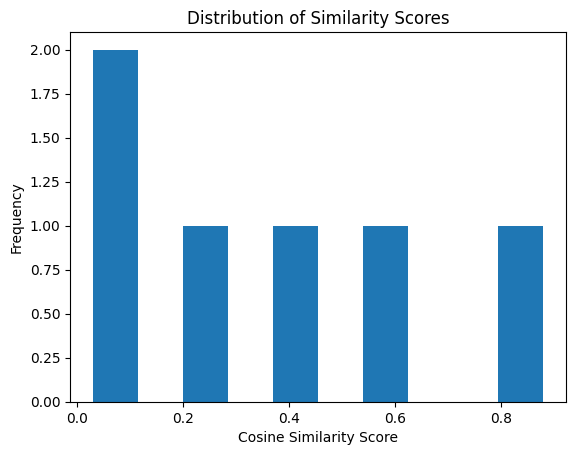

In [8]:
plt.hist(scores, bins=10)
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Similarity Scores")
plt.show()

## Observations

- High similarity scores typically indicate strong semantic relevance
- Medium scores may represent partial topic overlap
- Low scores indicate unrelated content

## Key Insight
Similarity scores should be interpreted relatively within a ranking,
rather than using strict universal thresholds.